# Overview

This script will re-cluster cells after they have been assigned to an Allen cell type. Briefly, the script will load in pre-clustered AnnData objects produced by `preprocessing.ipynb`. It will also load in an adata object containing filtered cells with normalized counts, but where highly variable genes have not been selected and clustering has not occurred. These two objects will be merged to preserve Allen cell-type assignment for the unprocessed cells. Any cells not assigned to the Allen cell type of interest will be discarded. Then, HVG selection and clustering will occur:

0. import `adata.h5ad` with cluster data and `adata_preFeatureSelection.h5ad`
1. merge metadata information for both AnnData objects
2. delete all cells not assigned to cell type of interest
4. selection for highly variable genes (HVGs)
5. regress out count information as a covariate
6. scale data to unit variance
7. dimension reduction using PCA
8. make a neighborhood graph (if combining sublibraries, use the BBKNN method)
9. Louvain-cluster cells
10. assign cells to Allen clusters using *raw* counts *after* filtering
11. map Allen types to colormap
12. save AnnData object
13. plot results!

In [1]:
import os
import clusta
import warnings
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'avenir'
plt.rcParams['figure.dpi'] = 150

/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/numba/core/cpu.py:99: UserWarning: Numba extension module 'sparse._numba_extension' failed to load due to 'ModuleNotFoundError(No module named 'numba.targets')'.
  numba.core.entrypoints.init_all()


In [2]:
sublib = 'sublibrary1'

data_path = f'/Volumes/jack/seq/analysis/{sublib}/0_all-sample/DGE_filtered/'

In [3]:
### 0. import AnnData objects
adata_clustered = sc.read_h5ad(os.path.join(data_path, 'adata.h5ad'))  # has Allen taxonomy metadata
adata_preFeatSelection = sc.read_h5ad(os.path.join(data_path, 'adata_preFeatSelection.h5ad')) # has not been clustered

### 1. merge metadata from both AnnData objects
adata_preFeatSelection.obs['subclass_label'] = adata_preFeatSelection.obs.join(adata_clustered.obs['subclass_label'])['subclass_label']

### 2. delete all cells not assigned to cell type of interest
# 016 CA1-ProS Glut --> CS20230722_SUBC_016
celltype = 'CS20230722_SUBC_016'
adata = adata_preFeatSelection[adata_preFeatSelection.obs['subclass_label']==celltype]
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,bc3_well,sublibrary,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_counts,n_genes,size_factors,subclass_label
07_02_05,1h1,mm39,4373,19003,30434,7,2,5,A7,A2,A5,sublibrary1,4373,19003.0,0.0,0.000000,19002.0,4372,0.932656,CS20230722_SUBC_016
07_02_48,1h1,mm39,4389,19382,30956,7,2,48,A7,A2,D12,sublibrary1,4389,19382.0,0.0,0.000000,19381.0,4388,0.937079,CS20230722_SUBC_016
07_02_53,1h1,mm39,3538,16268,26171,7,2,53,A7,A2,E5,sublibrary1,3538,16268.0,1.0,0.006147,16268.0,3538,0.656798,CS20230722_SUBC_016
07_02_60,1h1,mm39,3072,14313,22819,7,2,60,A7,A2,E12,sublibrary1,3072,14313.0,2.0,0.013973,14313.0,3072,0.570022,CS20230722_SUBC_016
07_03_50,1h1,mm39,3643,17864,28285,7,3,50,A7,A3,E2,sublibrary1,3643,17864.0,0.0,0.000000,17864.0,3643,0.734133,CS20230722_SUBC_016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
06_94_47,SE3,mm39,5392,31464,50887,6,94,47,A6,H10,D11,sublibrary1,5392,31464.0,2.0,0.006356,31462.0,5390,1.415772,CS20230722_SUBC_016
06_95_32,SE3,mm39,5368,29537,47834,6,95,32,A6,H11,C8,sublibrary1,5368,29537.0,3.0,0.010157,29535.0,5366,1.343465,CS20230722_SUBC_016
06_96_07,SE3,mm39,4130,19229,31074,6,96,7,A6,H12,A7,sublibrary1,4130,19229.0,1.0,0.005200,19228.0,4129,0.860553,CS20230722_SUBC_016
06_96_24,SE3,mm39,4573,20320,32657,6,96,24,A6,H12,B12,sublibrary1,4573,20320.0,0.0,0.000000,20320.0,4573,0.961422,CS20230722_SUBC_016


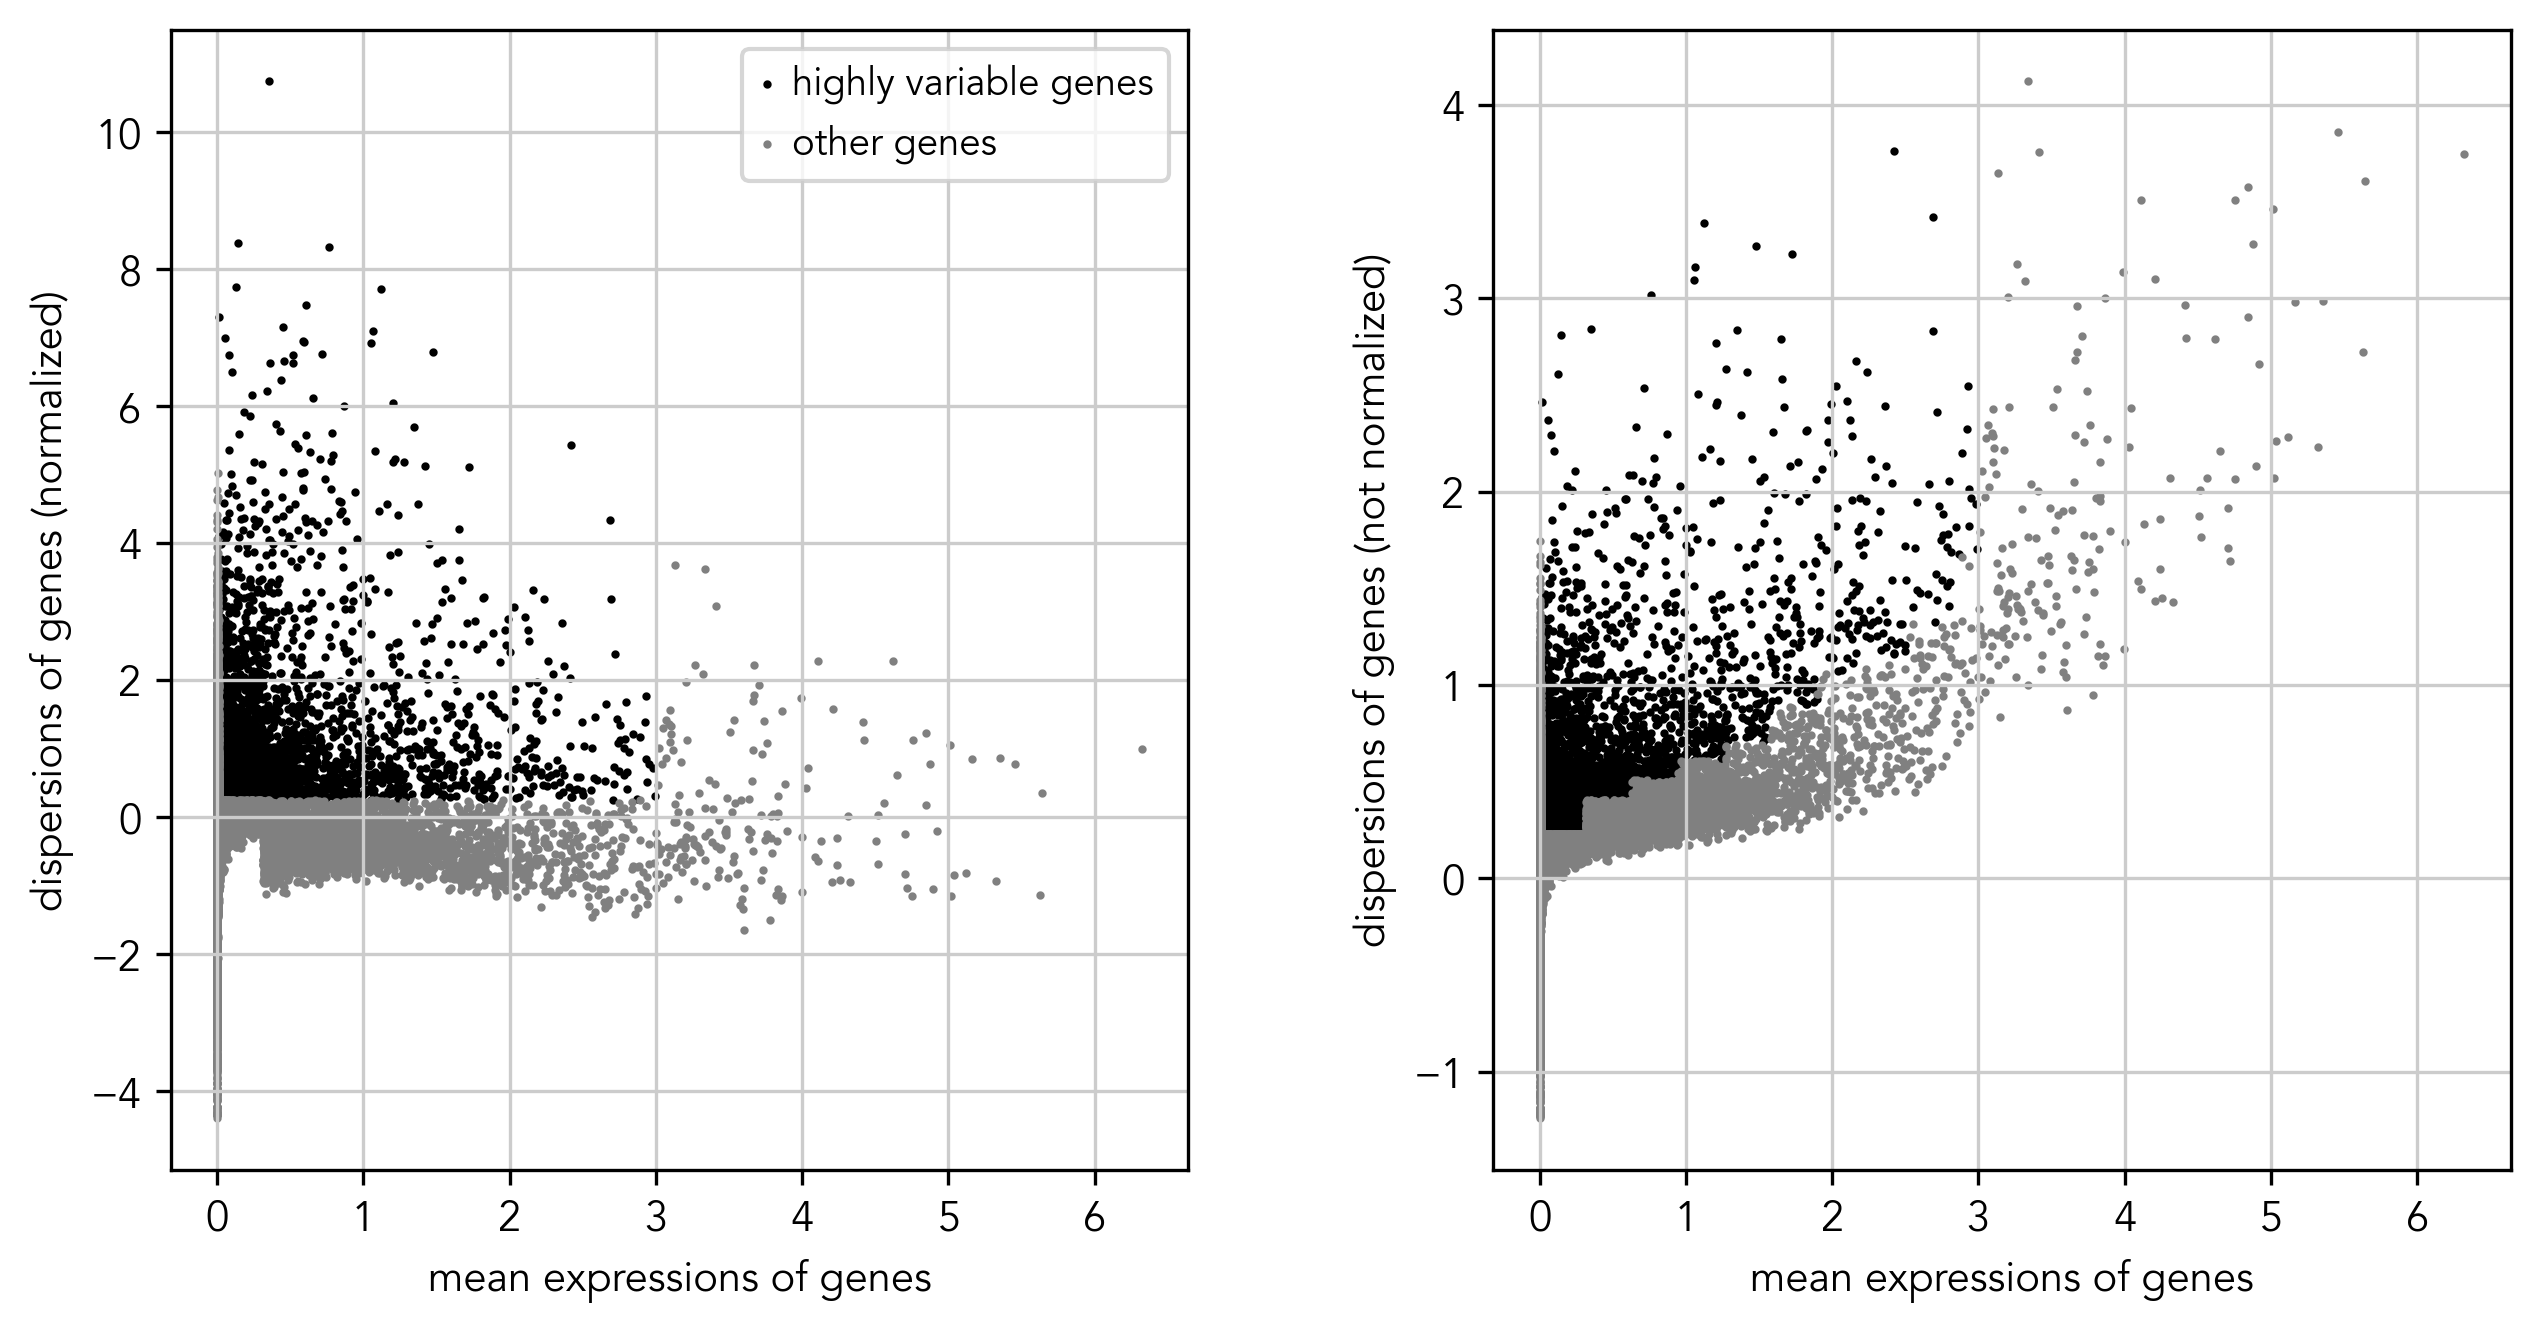

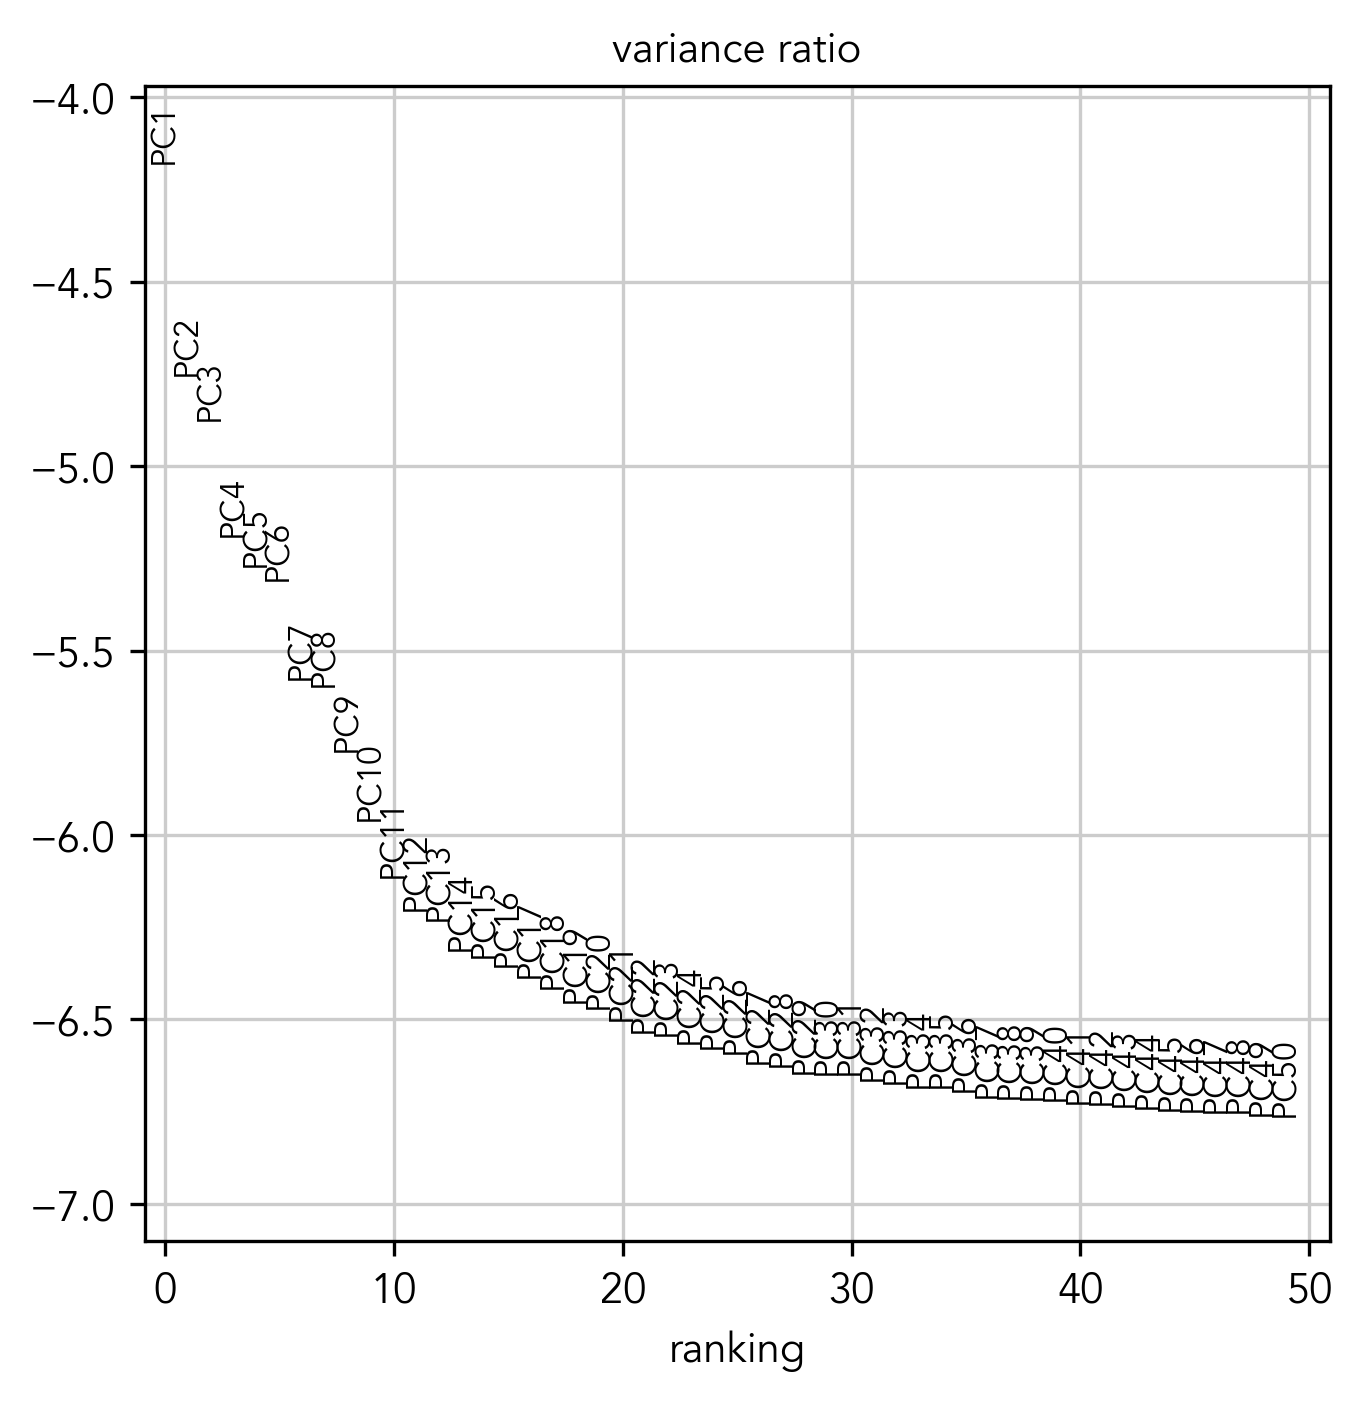

In [4]:
### 3. select for highly variable genes
adata = clusta.select_hvgs(adata)

### 4. regress out total counts
adata = clusta.regress_out_covariates(adata)

### 5. scale data
adata = clusta.scale_data(adata)

### 6. run PCA
adata = clusta.run_pca(adata)

In [5]:
# user needs to pick this based off of scree plot
num_PCs_to_use = 31

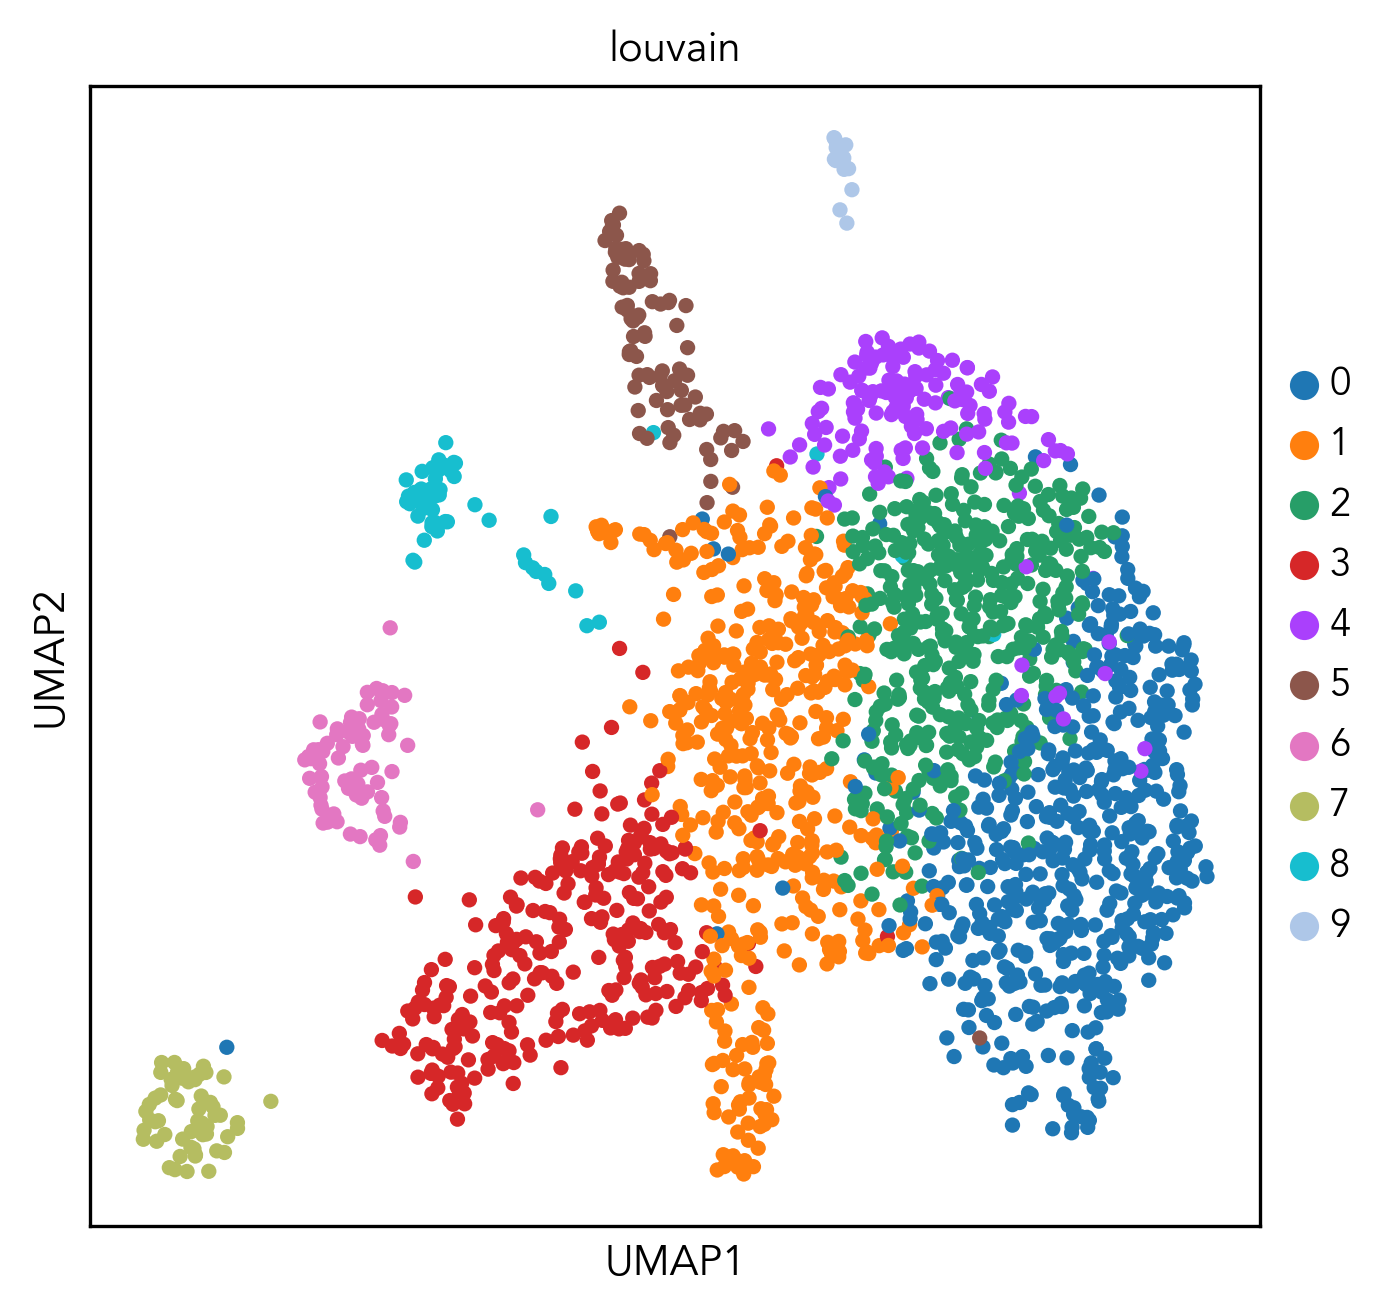

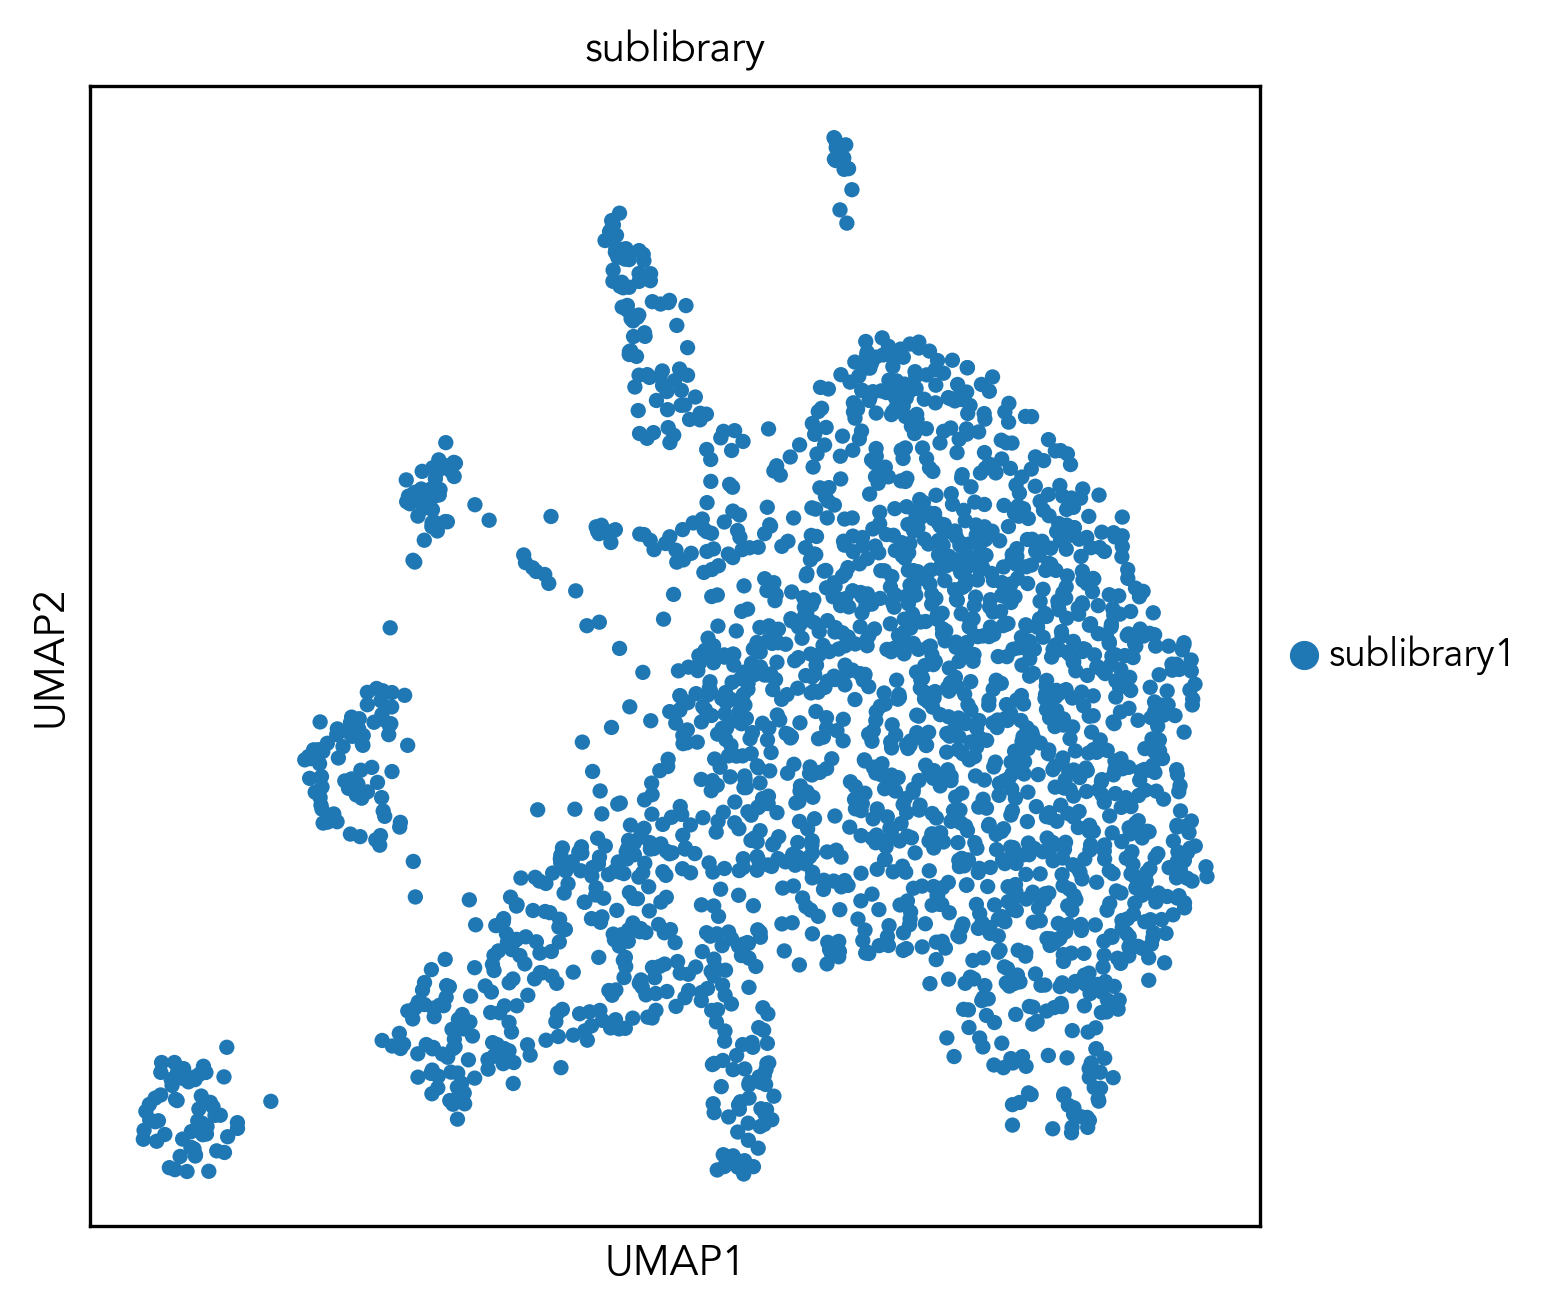

In [6]:
### 7. make neighborhood graph
adata = clusta.make_neighborhood_graph(adata, num_PCs_to_use=num_PCs_to_use)

### 8. louvain clustering
adata = clusta.louvain_cluster(adata)

### 9. map cells to Allen clusters
clusta.make_adata_lean(adata, 'adata_lean_subclass016.h5ad')

~Map cells using online tool, save to file~

In [9]:
csv_path = 'adata_lean_subclass016_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1706286055340/adata_lean_subclass016_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1706286055340.csv'

In [12]:
### 10. merge Allen cell type taxonomy assignment
adata.obs['subclass_label_old'] = adata.obs['subclass_label']
adata.obs.drop('subclass_label', axis=1, inplace=True)

adata = clusta.merge_allen_celltypes(adata, csv_path)

In [13]:
### 11. assign Allen taxonomy colors
adata = clusta.get_taxonomy_cmap(adata)

### 12. save AnnData object
adata.write_h5ad(os.path.join(data_path, f'adata_{celltype}.h5ad'))

IORegistryError: No method registered for writing <class 'collections.OrderedDict'> into <class 'h5py._hl.group.Group'>

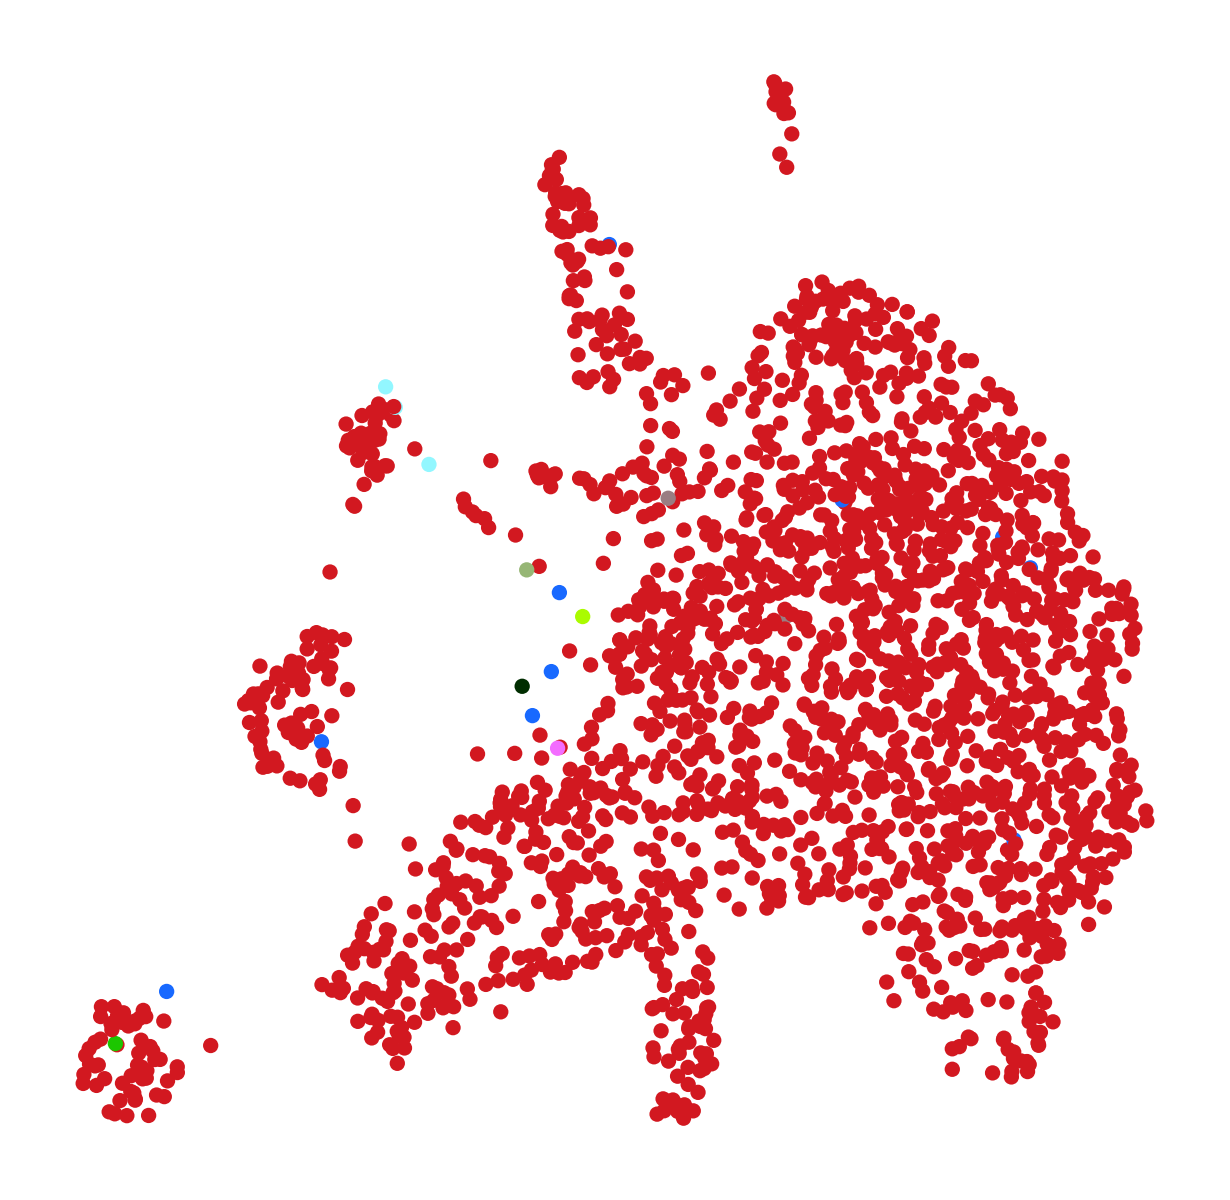

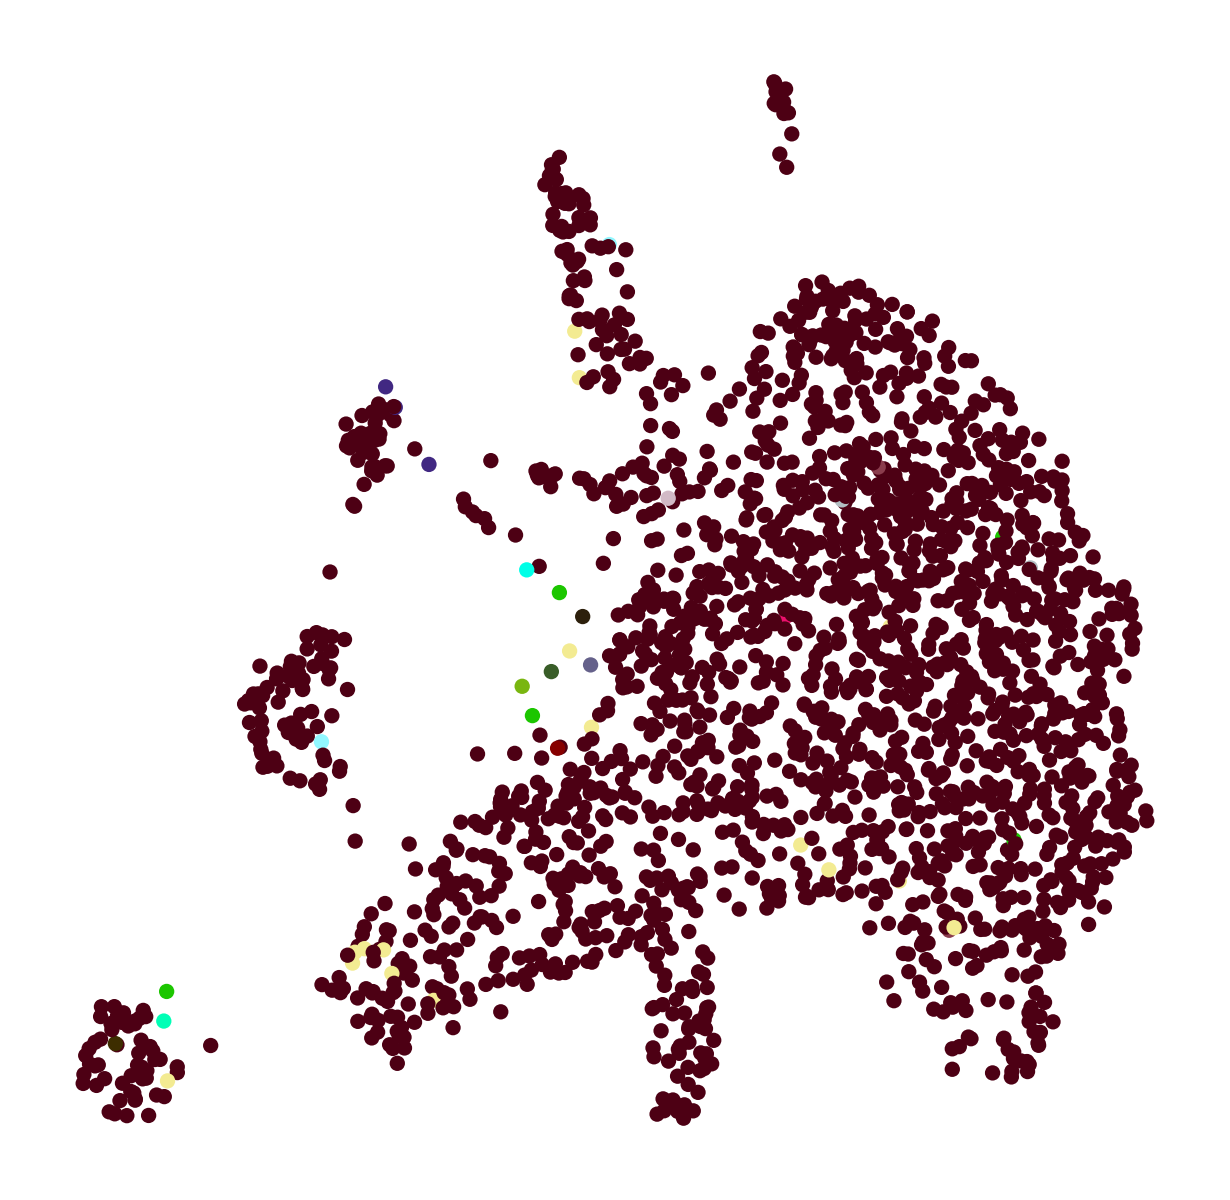

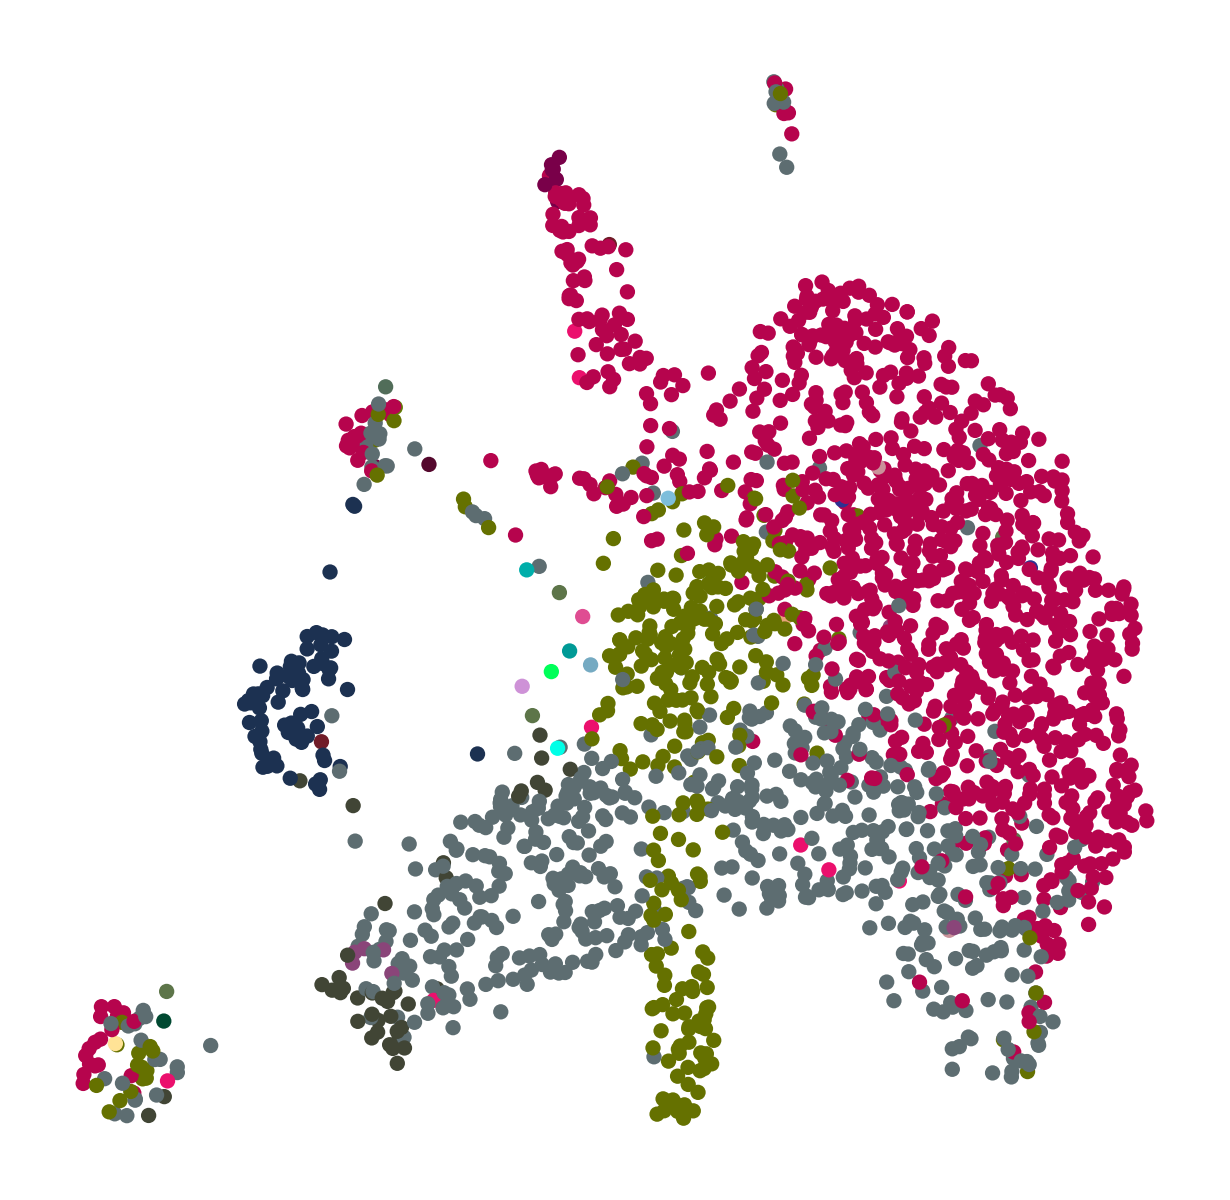

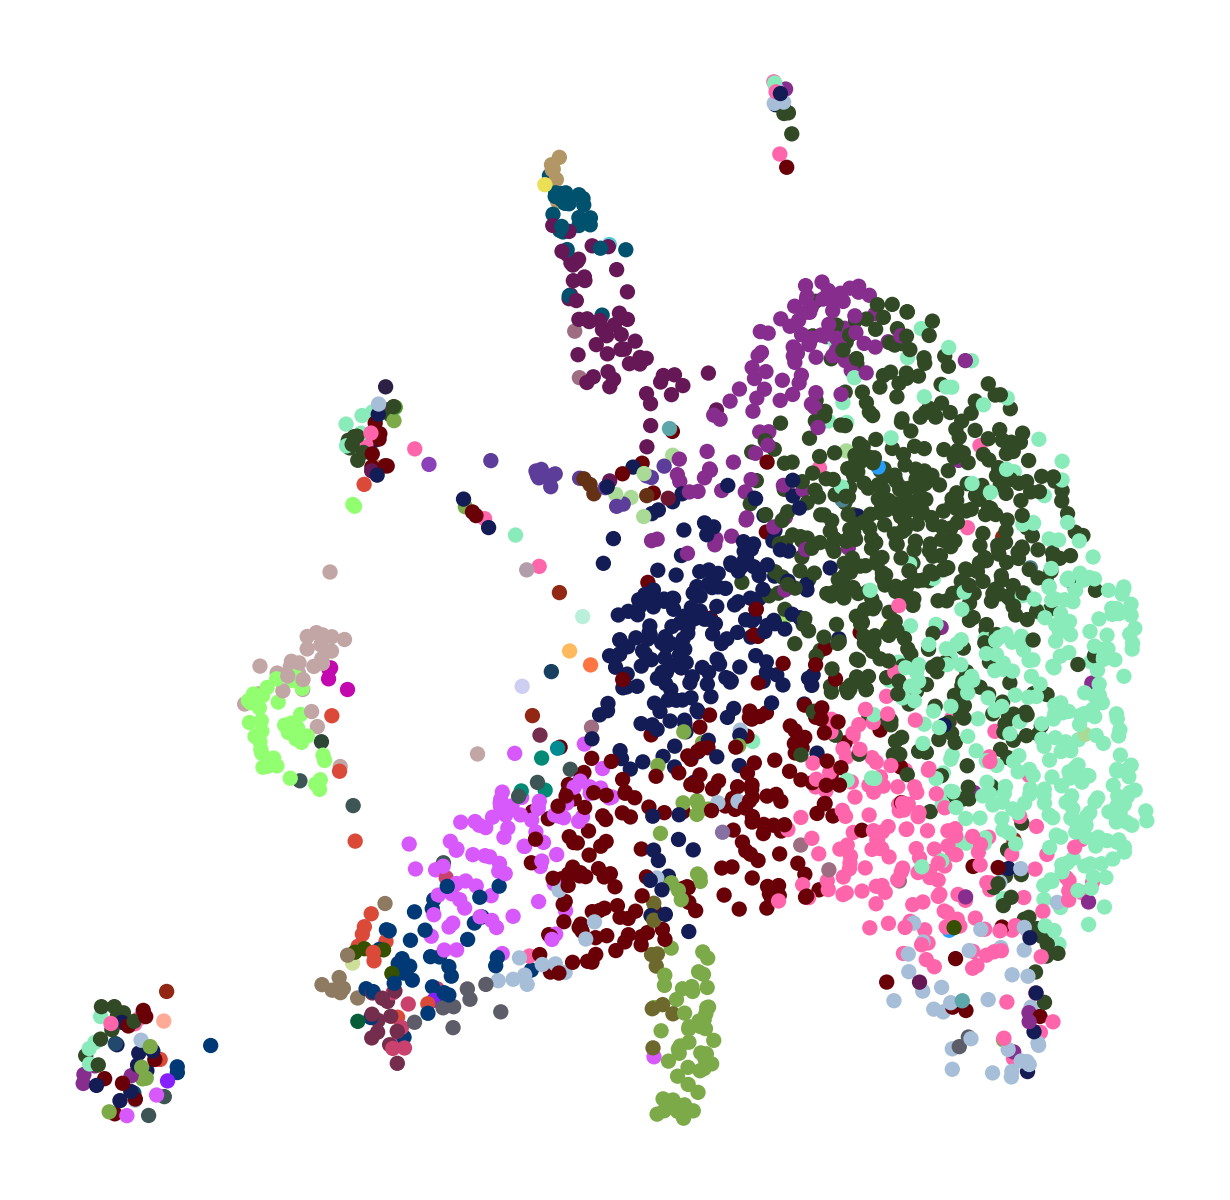

In [16]:
### 13. plot results
labs = ['class_name', 'subclass_name', 'supertype_name', 'cluster_name']
for lab in labs:
    sc.pl.umap(adata, color=[lab], show=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().set_xlabel('')
    plt.gca().set_ylabel('')
    plt.gca().set_title('')
    plt.gca().get_legend().remove()